# Cartesian Octree Read Example

Read 3d__var_3_n00004000.dat and build a Cartesian octree.

In [1]:
from pathlib import Path
import sys


def repo_root() -> Path:
    """Find repository root by locating local package/data folders."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "example_data").is_dir() and (candidate / "batcamp").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate repository root with example_data/ and batcamp/.")


REPO_ROOT = repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from starwinds_readplt.dataset import Dataset
from batcamp import Octree
from batcamp import format_octree_summary


def data_file(name: str) -> Path:
    """Return path under local example_data directory."""
    return REPO_ROOT / "example_data" / name


In [2]:
data_path = data_file('3d__var_3_n00004000.dat')
print(data_path)
assert data_path.exists()

/Users/dagfev/Documents/starwinds/batcamp/example_data/3d__var_3_n00004000.dat


In [3]:
ds = Dataset.from_file(str(data_path))
print(ds)

Title:     'BATSRUS: 3D Data, 1998/05/05 00:00:00.000'
Zone:      '3D   N=0004000'
Variables: 16
Shape:     (542481, 16)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [amu/cm^3]', 'U_x [km/s]', 'U_y [km/s]', 'U_z [km/s]', 'B_x [nT]', 'B_y [nT]', 'B_z [nT]', 'P [nPa]', 'J_x [`uA/m^2]', 'J_y [`uA/m^2]', 'J_z [`uA/m^2]', 'XUVTAU [none]', 'XUVHEAT [W/m^3]'].


In [4]:
tree = Octree.from_dataset(ds, tree_coord='xyz')
print(format_octree_summary(tree))
print('levels:', tree.levels)
print('is_uniform:', tree.is_uniform)

Octree (adaptive): tree_coord=xyz, finest_leaf_grid=(1280, 1280, 1280), root_grid=(5, 5, 5), depth=8, full=True, levels=0..5; leaf_levels[L0:48000 (fine-equiv 1572864000), L1:112000 (fine-equiv 458752000), L2:112000 (fine-equiv 57344000), L3:120000 (fine-equiv 7680000), L4:56000 (fine-equiv 448000), L5:64000 (fine-equiv 64000)]
levels: (0, 1, 2, 3, 4, 5)
is_uniform: False


In [5]:
center = tree.lookup._cell_centers[len(tree.lookup._cell_centers) // 2]
hit = tree.lookup_point(center, space='xyz')
print('center:', center)
print('cell_id:', None if hit is None else hit.cell_id)
print('level:', None if hit is None else hit.level)

center: [-220.8 -124.8    3.2]
cell_id: 256000
level: 0


## XY Plane Resample (log rho)

Resample on z=0 with the octree interpolator and plot log10 of rho.

In [6]:
from batcamp import OctreeInterpolator
import numpy as np
import matplotlib.pyplot as plt

In [7]:
interp = OctreeInterpolator(ds, ['Rho [amu/cm^3]'], tree=tree)

centers = np.asarray(tree.lookup._cell_centers, dtype=float)
xmin, xmax = float(np.min(centers[:, 0])), float(np.max(centers[:, 0]))
ymin, ymax = float(np.min(centers[:, 1])), float(np.max(centers[:, 1]))

nx, ny = 300, 300
x = np.linspace(xmin, xmax, nx)
y = np.linspace(ymin, ymax, ny)
xx, yy = np.meshgrid(x, y, indexing='xy')
zz = np.zeros_like(xx)
q = np.column_stack((xx.ravel(), yy.ravel(), zz.ravel()))

rho, cell_ids = interp(q, query_coord='xyz', return_cell_ids=True)
rho = np.asarray(rho, dtype=float).reshape(ny, nx)
cell_ids = np.asarray(cell_ids, dtype=int).reshape(ny, nx)

mask = cell_ids < 0
rho = np.where(mask, np.nan, rho)
rho = np.where(rho > 0.0, rho, np.nan)
log_rho = np.log10(rho)

print('grid:', (ny, nx))
print('valid fraction:', float(np.mean(~np.isnan(log_rho))))


grid: (300, 300)
valid fraction: 1.0


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


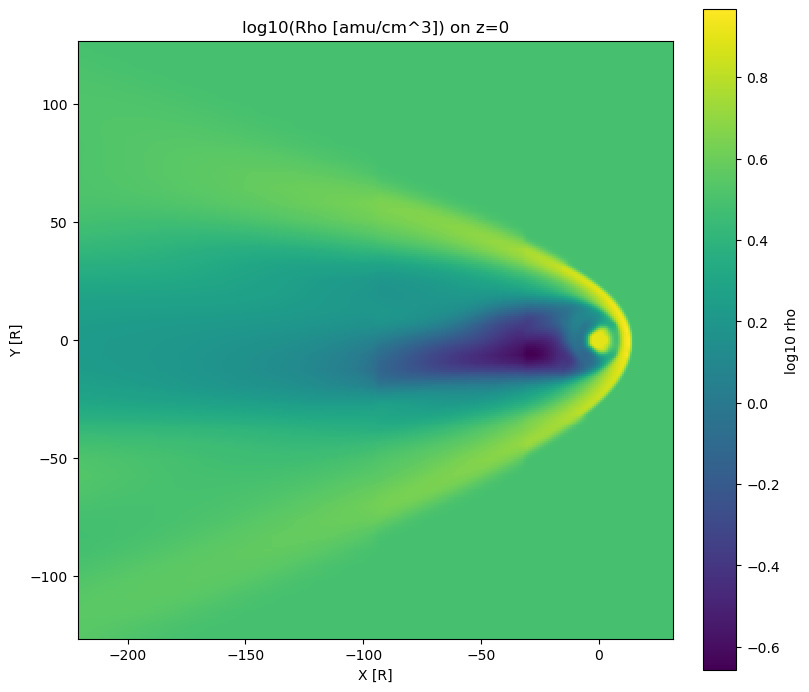

In [8]:
fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
im = ax.pcolormesh(xx, yy, log_rho, shading='auto', cmap='viridis')
ax.set_xlabel('X [R]')
ax.set_ylabel('Y [R]')
ax.set_title('log10(Rho [amu/cm^3]) on z=0')
ax.set_aspect('equal')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('log10 rho')
plt.show()


## Ray Demo: Column Quantity

Sample a very small set of rays through the Cartesian domain, compute `2 * rho * temp` along each ray, and integrate along path length to get a column value per ray.

If a temperature variable is missing in this file, use `P/rho` as a temperature proxy for the demo.



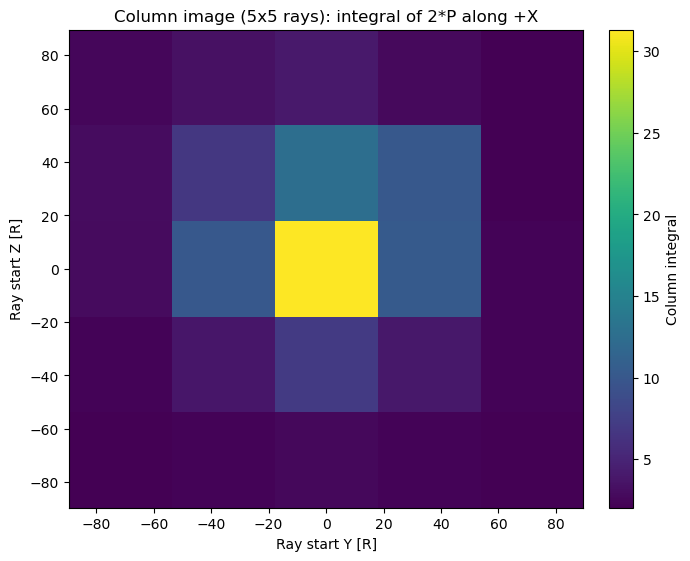

computed quantity: integral of 2*P along ray (equivalent to 2*rho*(P/rho))
grid shape: (5, 5)
column min/max: 2.03338615400106 31.320796999584992


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from batcamp import OctreeInterpolator
from batcamp import OctreeRayInterpolator

# Fast column demo: integrate 2*P along +X using batched ray integration.
p_interp = OctreeInterpolator(ds, ['P [nPa]'], tree=tree)
ray_interp = OctreeRayInterpolator(p_interp)

points_xyz = np.asarray(tree.lookup._points, dtype=float)
dmin = points_xyz.min(axis=0)
dmax = points_xyz.max(axis=0)

xmin, ymin, zmin = dmin
xmax, ymax, zmax = dmax

yc = 0.5 * (ymin + ymax)
zc = 0.5 * (zmin + zmax)
y_span = 0.35 * (ymax - ymin)
z_span = 0.35 * (zmax - zmin)

ny, nz = 5, 5
y_vals = np.linspace(yc - y_span, yc + y_span, ny)
z_vals = np.linspace(zc - z_span, zc + z_span, nz)

ray_dir = np.array([1.0, 0.0, 0.0], dtype=float)
L = float(xmax - xmin)

origins = np.empty((ny * nz, 3), dtype=float)
k = 0
for z0 in z_vals:
    for y0 in y_vals:
        origins[k] = (xmin, y0, z0)
        k += 1

# scale=2.0 gives integral of 2*P along the ray.
col_flat = ray_interp.integrate_field_along_rays(
    origins,
    ray_dir,
    0.0,
    L,
    chunk_size=4096,
    scale=2.0,
)
col_img = np.asarray(col_flat, dtype=float).reshape(nz, ny)

fig, ax = plt.subplots(figsize=(6.8, 5.5), constrained_layout=True)
im = ax.imshow(
    col_img,
    origin='lower',
    extent=[y_vals.min(), y_vals.max(), z_vals.min(), z_vals.max()],
    aspect='auto',
    cmap='viridis',
)
ax.set_xlabel('Ray start Y [R]')
ax.set_ylabel('Ray start Z [R]')
ax.set_title('Column image (5x5 rays): integral of 2*P along +X')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Column integral')
plt.show()

print('computed quantity: integral of 2*P along ray (equivalent to 2*rho*(P/rho))')
print('grid shape:', col_img.shape)
print('column min/max:', float(np.nanmin(col_img)), float(np.nanmax(col_img)))
